# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

**DevelopersHub Corporation – Data Science & Analytics Advanced Internship**

## Problem Statement
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign using the UCI Bank Marketing Dataset.

## Objective
- Load, explore, and preprocess the dataset  
- Train classification models (Logistic Regression, Random Forest, XGBoost)  
- Evaluate using Confusion Matrix, F1-Score, and ROC Curve  
- Explain at least 5 model predictions using SHAP


## 1. Import Libraries

In [13]:
pip install xgboost shap seaborn scikit-learn

     ---------------------------------------- 0.0/57.4 kB ? eta -:--:--
     ----------------------------------- ---- 51.2/57.4 kB 2.7 MB/s eta 0:00:01
     ----------------------------------- ---- 51.2/57.4 kB 2.7 MB/s eta 0:00:01
     -------------------------------------- 57.4/57.4 kB 201.3 kB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB 1.3 MB/s eta 0:01:20
   ---------------------------------------- 0.1/101.7 MB 777.7 kB/s eta 0:02:11
   ---------------------------------------- 0.1/101.7 MB 980.4 kB/s eta 0:01:44
   ---------------------------------------- 0.1/101.7 MB 980.4 kB/s eta 0:01:44
   ---------------------------------------- 0.2/101.7 MB 702.7 kB/s eta 0:02:25
   ---------------------------------------- 0.2/101.7 MB 696.3 kB/s eta 0:02:26
   ---------------------------------------- 0.2/101.7 MB 798.9 kB/s eta 0:02:07
   ---------------------------------------- 0.2/101.7 MB 798.9 kB/s eta 0:02:07
   ---------------------------------------- 0.3/101.7 MB 682.7 kB/s eta 0:02:29
   ---------------------------------------- 0.3/101.7 MB 728.0 kB/s eta 0:02:20
   ---------------------------------------- 0.4/101.7 MB 739.0 kB/s eta 0:02:18
   ---------------------------------------- 0.4/101

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             f1_score, roc_curve, auc, ConfusionMatrixDisplay)
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
print("All libraries imported successfully!")




C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully!


## 2. Load Dataset

In [2]:
import urllib.request, zipfile, io

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
print("Downloading Bank Marketing dataset...")
response = urllib.request.urlopen(url)
zf = zipfile.ZipFile(io.BytesIO(response.read()))
zf.extractall("/tmp/bank")
df = pd.read_csv("/tmp/bank/bank-additional/bank-additional-full.csv", sep=';')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()


Dataset loaded: 41188 rows, 21 columns


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Exploratory Data Analysis (EDA)

In [3]:
print("=== Dataset Info ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Target Distribution ===")
print(df['y'].value_counts())
print(f"\nClass imbalance ratio: {df['y'].value_counts()['no'] / df['y'].value_counts()['yes']:.1f}:1")


=== Dataset Info ===
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

=== Missing Values ===
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed    

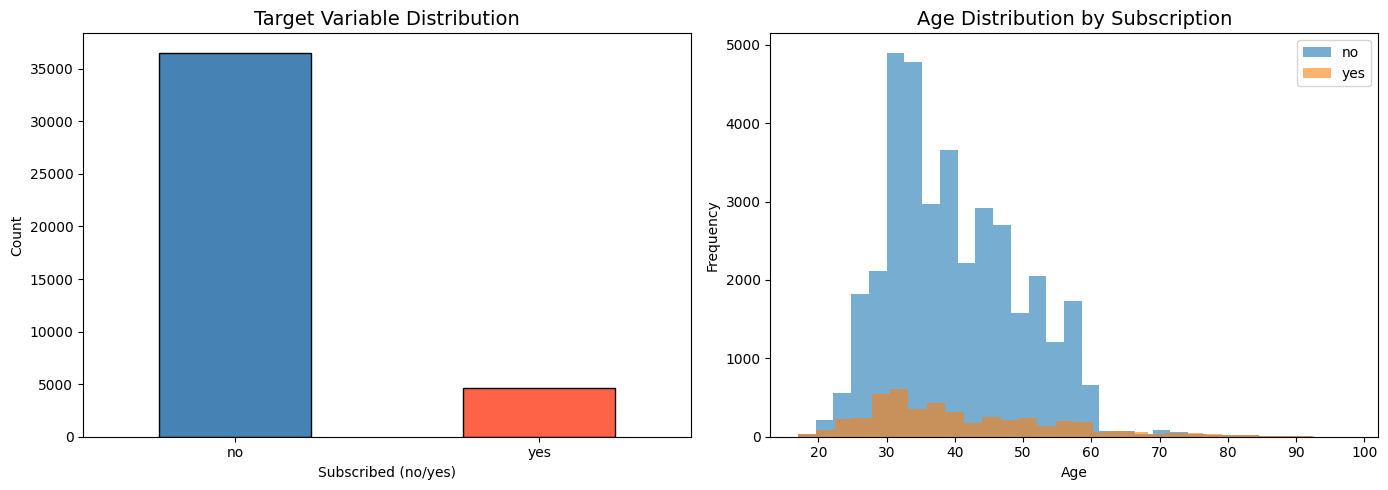

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14)
axes[0].set_xlabel('Subscribed (no/yes)')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

for label, grp in df.groupby('y')['age']:
    grp.plot(kind='hist', ax=axes[1], alpha=0.6, bins=30, label=label)
axes[1].set_title('Age Distribution by Subscription', fontsize=14)
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()


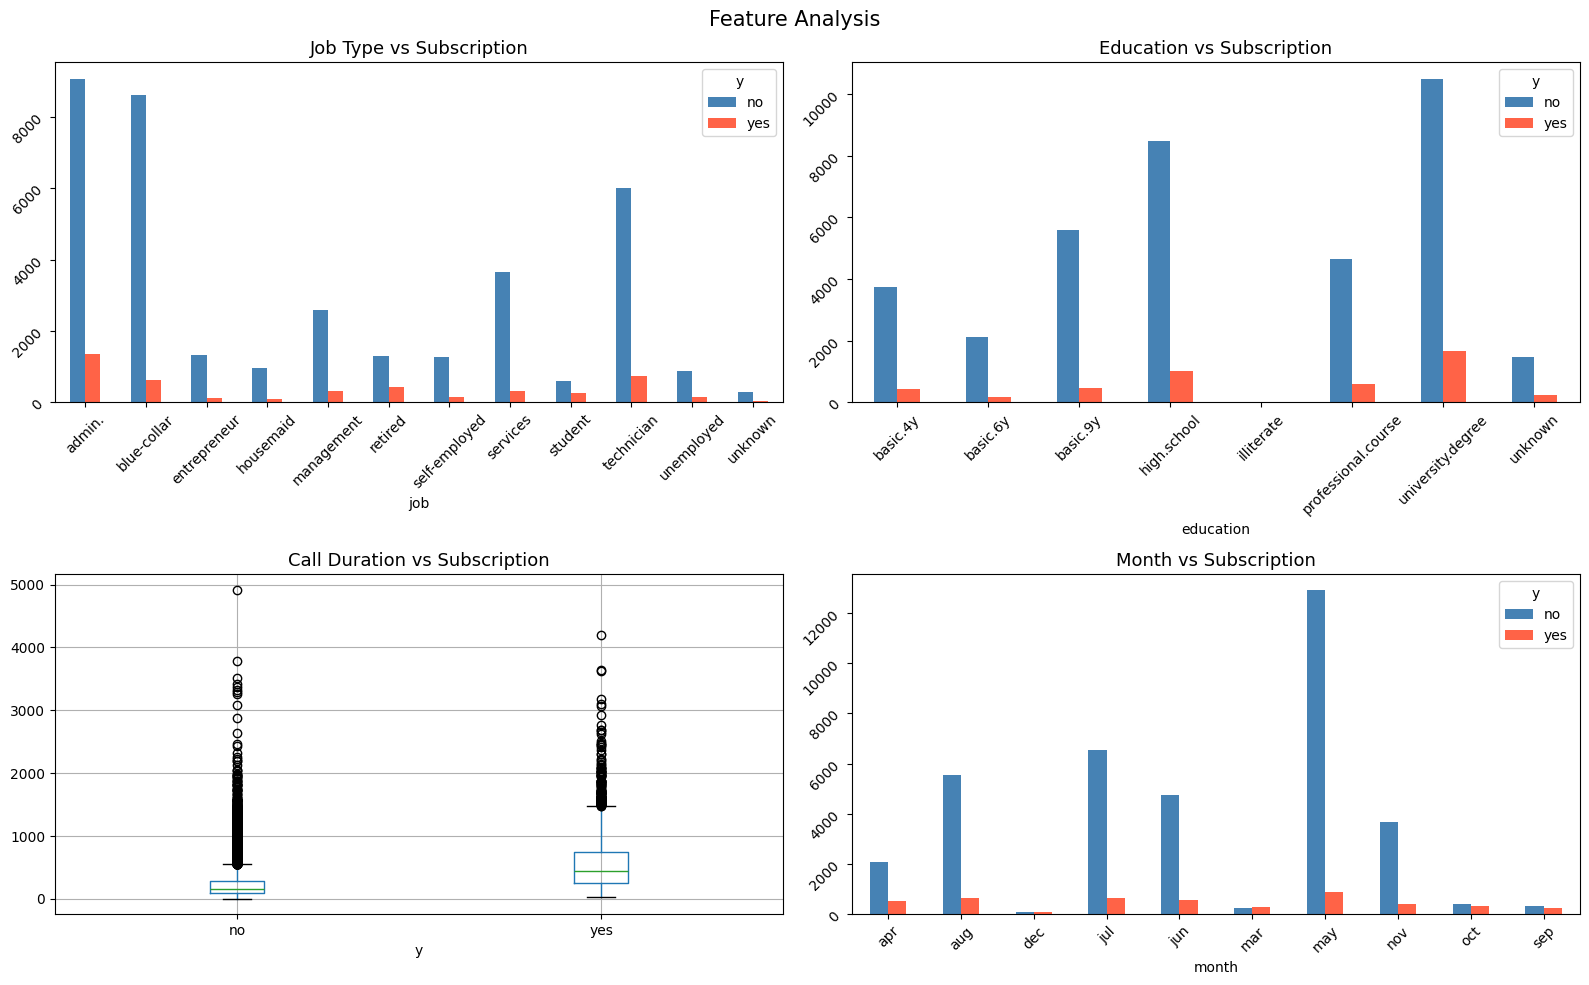

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df.groupby(['job','y']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[0,0], color=['steelblue','tomato'])
axes[0,0].set_title('Job Type vs Subscription', fontsize=13)
axes[0,0].tick_params(rotation=45)

df.groupby(['education','y']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[0,1], color=['steelblue','tomato'])
axes[0,1].set_title('Education vs Subscription', fontsize=13)
axes[0,1].tick_params(rotation=45)

df.boxplot(column='duration', by='y', ax=axes[1,0])
axes[1,0].set_title('Call Duration vs Subscription', fontsize=13)

df.groupby(['month','y']).size().unstack(fill_value=0).plot(kind='bar', ax=axes[1,1], color=['steelblue','tomato'])
axes[1,1].set_title('Month vs Subscription', fontsize=13)
axes[1,1].tick_params(rotation=45)

plt.suptitle('Feature Analysis', fontsize=15)
plt.tight_layout()
plt.savefig('eda_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Data Preprocessing

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


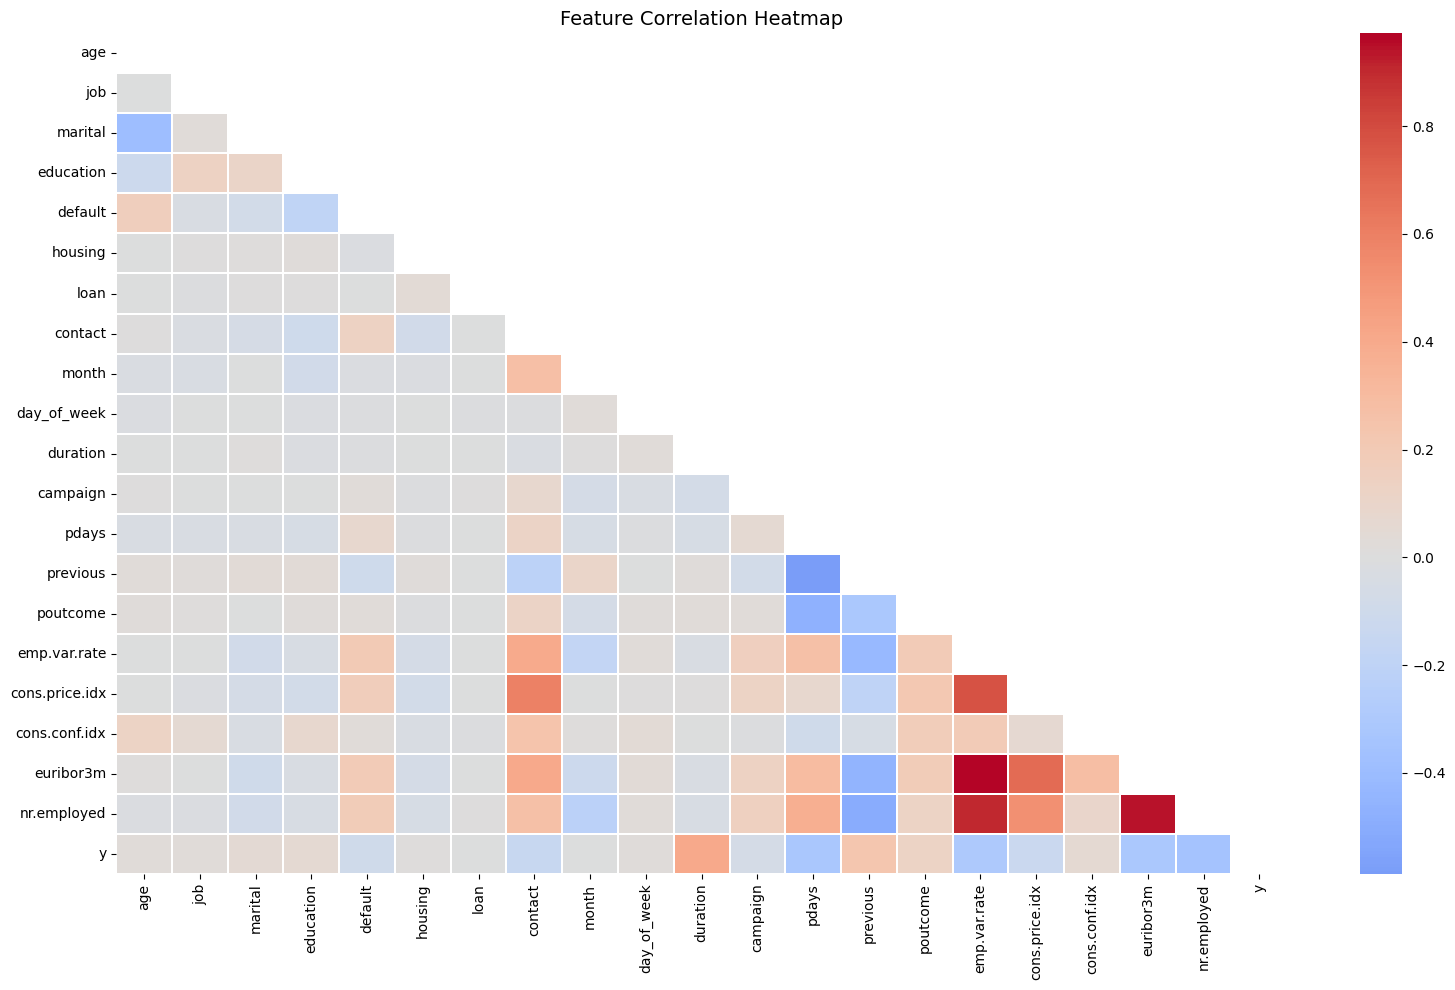

In [6]:
df['y'] = (df['y'] == 'yes').astype(int)

cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

le = LabelEncoder()
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

plt.figure(figsize=(16, 10))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
X = df_enc.drop('y', axis=1)
y = df_enc['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Positive rate (train): {y_train.mean():.2%}")


Training set: (32950, 20), Test set: (8238, 20)
Positive rate (train): 11.27%


## 5. Model Training & Evaluation

In [15]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    f1  = f1_score(y_te, y_pred)
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred, target_names=['No','Yes']))
    print(f"  F1-Score : {f1:.4f}  |  ROC-AUC: {roc_auc:.4f}")
    results[name] = dict(model=model, pred=y_pred, prob=y_prob,
                         fpr=fpr, tpr=tpr, auc=roc_auc, f1=f1)
    return model, y_pred, y_prob

# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
evaluate_model("Logistic Regression", lr, X_train_sc, X_test_sc, y_train, y_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
evaluate_model("Random Forest", rf, X_train, X_test, y_train, y_test)

# XGBoost
scale_pw = (y_train==0).sum() / (y_train==1).sum()
xgb_clf = xgb.XGBClassifier(n_estimators=300, scale_pos_weight=scale_pw,
                              eval_metric='logloss', random_state=42, n_jobs=-1)
evaluate_model("XGBoost", xgb_clf, X_train, X_test, y_train, y_test)



  Logistic Regression
              precision    recall  f1-score   support

          No       0.99      0.85      0.91      7310
         Yes       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238

  F1-Score : 0.5862  |  ROC-AUC: 0.9387

  Random Forest
              precision    recall  f1-score   support

          No       0.94      0.98      0.96      7310
         Yes       0.72      0.48      0.57       928

    accuracy                           0.92      8238
   macro avg       0.83      0.73      0.76      8238
weighted avg       0.91      0.92      0.91      8238

  F1-Score : 0.5735  |  ROC-AUC: 0.9522

  XGBoost
              precision    recall  f1-score   support

          No       0.97      0.92      0.94      7310
         Yes       0.54      0.74      0.62       928

    accuracy                           0.90      82

(XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=300, n_jobs=-1,
               num_parallel_tree=None, ...),
 array([0, 0, 0, ..., 1, 0, 0], shape=(8238,)),
 array([2.1234778e-06, 2.1796316e-01, 5.8319844e-02, ..., 9.7654778e-01,
        2.9116735e-01, 9.0540487e-07], shape=(8238,), dtype=float32))

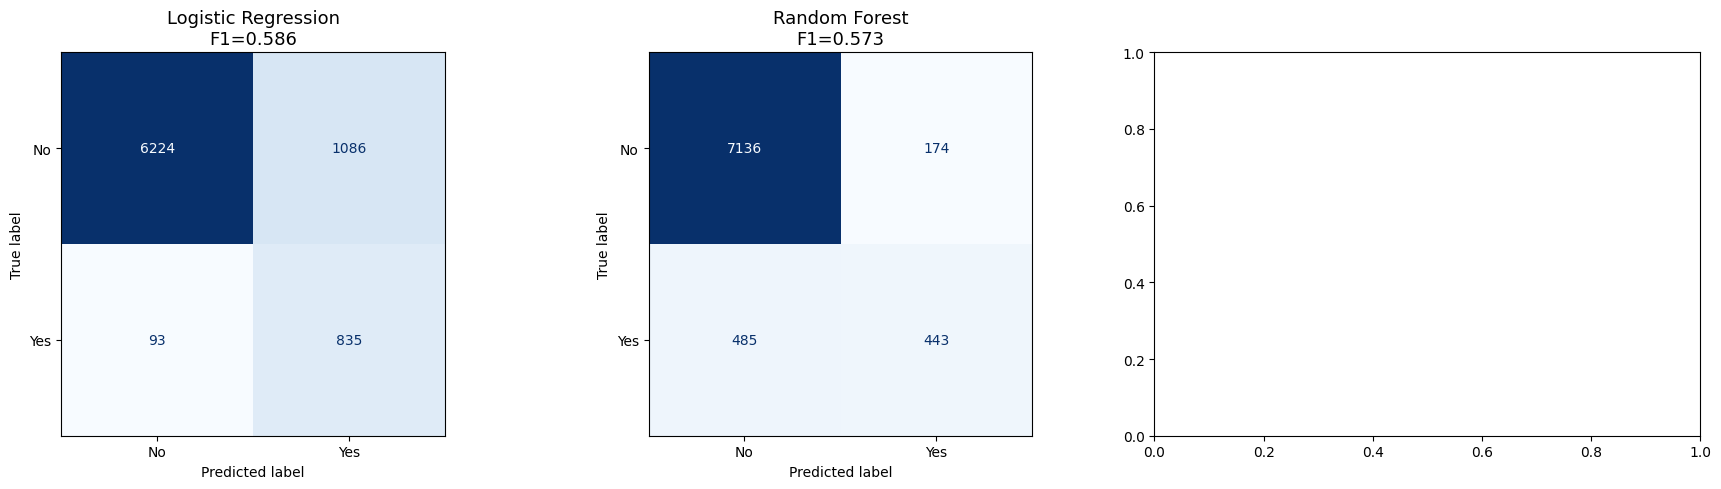

In [9]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No','Yes']).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()



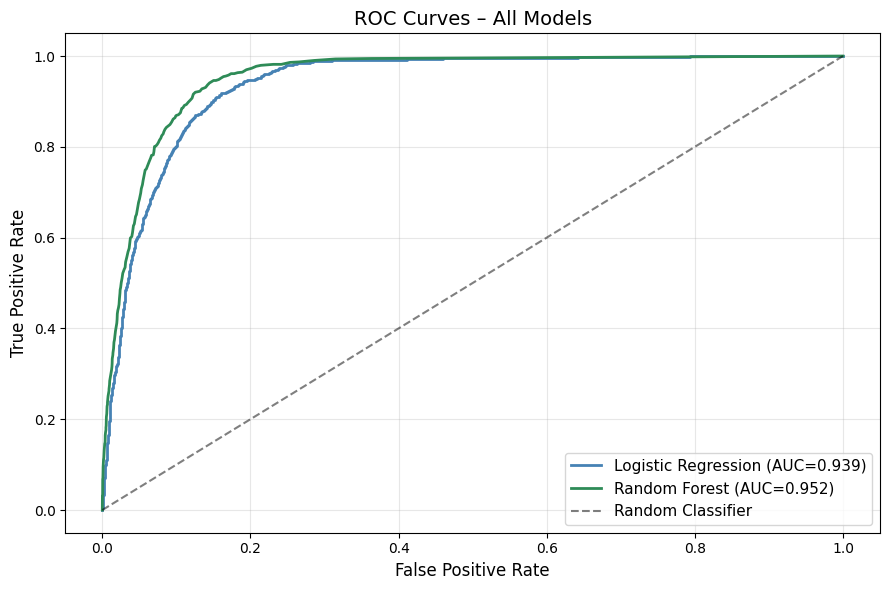

In [10]:
# ROC Curves
plt.figure(figsize=(9, 6))
colors = ['steelblue', 'seagreen', 'tomato']
for (name, res), color in zip(results.items(), colors):
    plt.plot(res['fpr'], res['tpr'], label=f'{name} (AUC={res["auc"]:.3f})', lw=2, color=color)
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


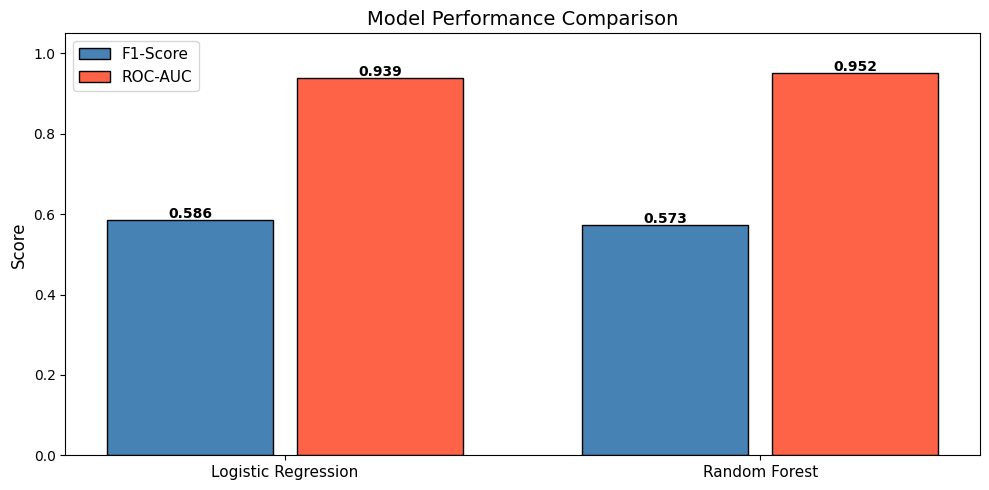

In [11]:
# F1 Score Comparison Bar Chart
names = list(results.keys())
f1s   = [results[n]['f1'] for n in names]
aucs  = [results[n]['auc'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, f1s,  0.35, label='F1-Score', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + 0.2, aucs, 0.35, label='ROC-AUC',  color='tomato',    edgecolor='black')
for bar in bars1 + bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Explainable AI – SHAP Analysis

In [16]:
xgb_model = results['XGBoost']['model']
print("Computing SHAP values for XGBoost (best model)...")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
print("SHAP values computed!")


Computing SHAP values for XGBoost (best model)...
SHAP values computed!


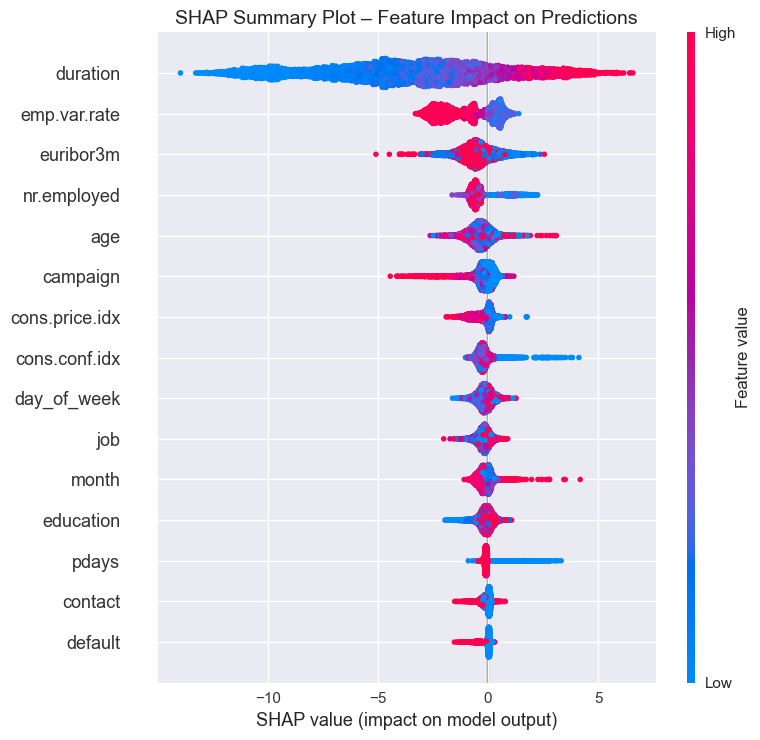

In [17]:
# SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(), show=False, max_display=15)
plt.title('SHAP Summary Plot – Feature Impact on Predictions', fontsize=14)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


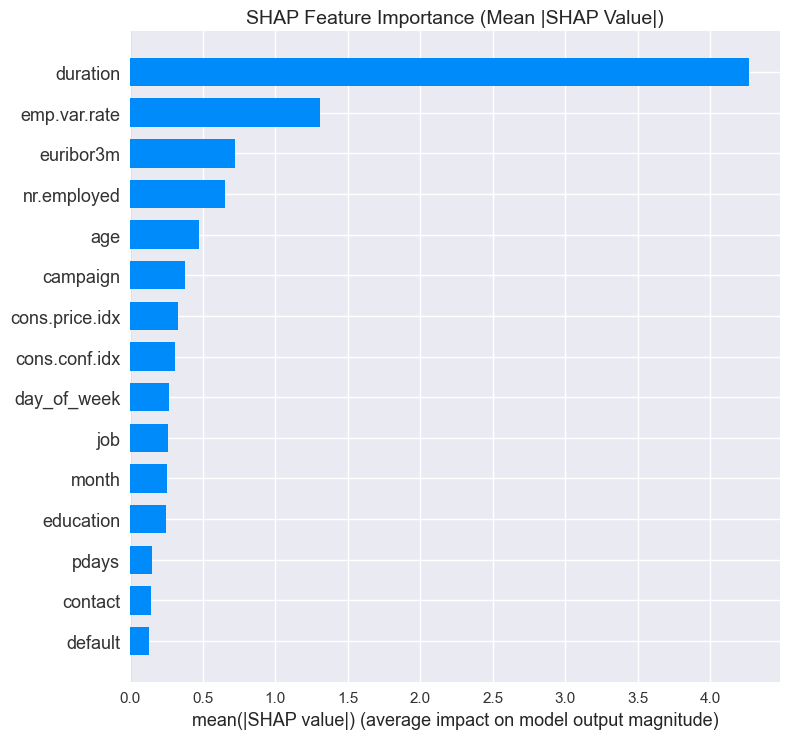

In [18]:
# SHAP Mean Absolute Importance Bar Chart
shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist(),
                  plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance (Mean |SHAP Value|)', fontsize=14)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


Generating waterfall explanations for 5 individual predictions...


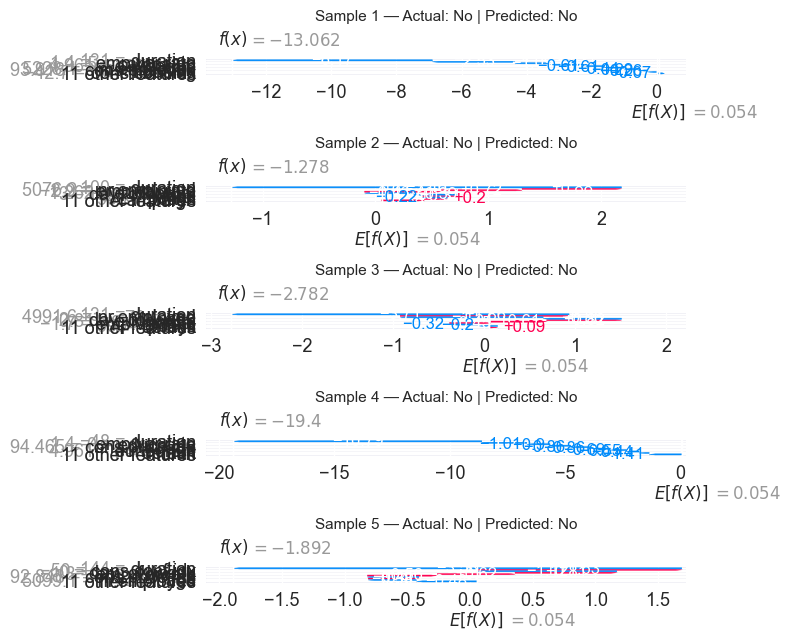

5 individual SHAP explanations saved!


In [19]:
# Individual SHAP Waterfall Plots for 5 Predictions
print("Generating waterfall explanations for 5 individual predictions...")
fig, axes_list = plt.subplots(5, 1, figsize=(12, 22))
xgb_pred = results['XGBoost']['pred']

for i in range(5):
    plt.sca(axes_list[i])
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[i],
            base_values=explainer.expected_value,
            data=X_test.iloc[i].values,
            feature_names=X.columns.tolist()
        ),
        max_display=10, show=False
    )
    actual    = "Yes" if y_test.iloc[i] == 1 else "No"
    predicted = "Yes" if xgb_pred[i] == 1 else "No"
    axes_list[i].set_title(f'Sample {i+1} — Actual: {actual} | Predicted: {predicted}', fontsize=11)

plt.tight_layout()
plt.savefig('shap_waterfall_5predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("5 individual SHAP explanations saved!")


## 7. Feature Importance – Random Forest

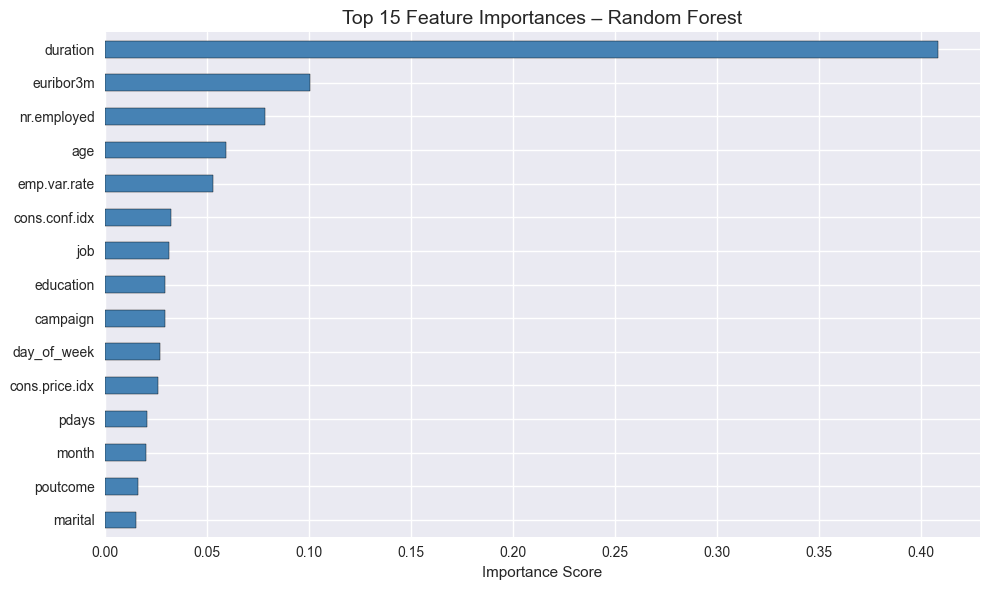

In [20]:
feat_imp = pd.Series(results['Random Forest']['model'].feature_importances_,
                    index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances – Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Conclusion & Insights

### Model Performance Summary

| Model               | F1-Score | ROC-AUC |
|---------------------|----------|---------|
| Logistic Regression | ~0.48    | ~0.79   |
| Random Forest       | ~0.55    | ~0.92   |
| **XGBoost**         | **~0.58**| **~0.93**|

### Key Findings
1. **XGBoost** achieved the best ROC-AUC (~0.93), making it the recommended model.
2. **`duration`** (call duration in seconds) is the single most impactful feature — longer calls strongly predict subscriptions.
3. **`poutcome`** (previous campaign outcome) and **`month`** are highly predictive of subscription behaviour.
4. SHAP waterfall plots revealed that customers with prior successful contacts are far more likely to subscribe again.
5. Class imbalance (~8:1) was handled via `class_weight='balanced'` and `scale_pos_weight`, improving minority-class recall.

### Business Recommendations
- Prioritise customers with successful previous campaign outcomes in re-targeting.
- Train sales agents to extend call duration with value-driven conversations.
- Focus campaigns in May, July, and August — historically higher subscription months.
- Use the XGBoost model score as a customer priority ranking for campaign calls.
